# Visualisation des résultats

On **visualise** l'évolution du système non supervisé :
1. **Accuracy de classification** qui monte pendant l'apprentissage (les neurones d'ancrage se spécialisent).
2. **Convergence S_auto** avec les images avant/après la boucle d'auto-évaluation.

## 0. Imports

In [1]:
# Visualisation — évolution de l'accuracy + convergence S_auto
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (load_mnist, AnchorNeurons, dynamic_k)
from recherche_agi.sensory_bundle import image_to_patches

## 1. Données + encodeur + ancres

In [2]:
train_set, test_set = load_mnist()

class WTAPredictiveEncoder:
    def __init__(self, d_in, d_out, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 1/np.sqrt(d_in), size=(d_out, d_in))
        self.d_in, self.d_out = d_in, d_out
        self.frozen = False
    def _fwd(self, x):
        y = self.W @ x
        ybin = np.zeros_like(y); ybin[np.argmax(y)] = y.max()
        return np.maximum(ybin, 0)
    def encode(self, x):
        x = x/(np.linalg.norm(x)+1e-8)
        y = self._fwd(x)
        return y/(np.linalg.norm(y)+1e-8)
    def learn(self, x, S):
        if self.frozen: return self.encode(x)
        x = x/(np.linalg.norm(x)+1e-8)
        y = self._fwd(x)
        eta = 0.5*S
        self.W = self.W + eta*(np.outer(y, x) - (y**2)[:,None]*self.W)
        self.W = self.W/(np.linalg.norm(self.W,axis=1,keepdims=True)+1e-8)
        return self.encode(x)
    def freeze(self): self.frozen = True

enc = WTAPredictiveEncoder(49, 32, seed=0)
cnt = [0]*10
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if cnt[l] >= 30: continue
    S = 0.3 + 0.5*np.random.rand()
    for p in image_to_patches(train_set[i][0].squeeze().numpy(), 7): enc.learn(p, S)
    cnt[l] += 1
    if sum(cnt) >= 300: break
enc.freeze()

def latent(img_np):
    return np.concatenate([enc.encode(p) for p in image_to_patches(img_np, 7)])

# test latents pré-extraits
test_latents = [latent(test_set[i][0].squeeze().numpy()) for i in range(len(test_set))]
test_labels = [int(test_set[i][1]) for i in range(len(test_set))]

def accuracy(anchors, n=200):
    c = t = 0
    for i in range(n):
        p, _ = anchors.predict_label(test_latents[i])
        if p is not None:
            t += 1
            if p == test_labels[i]: c += 1
    return c/t if t else 0

anchors = AnchorNeurons(d_in=512, n_neurons=50, seed=0, lr=0.1, use_homeostasis=True)

## 2. Évolution de l'accuracy pendant l'apprentissage

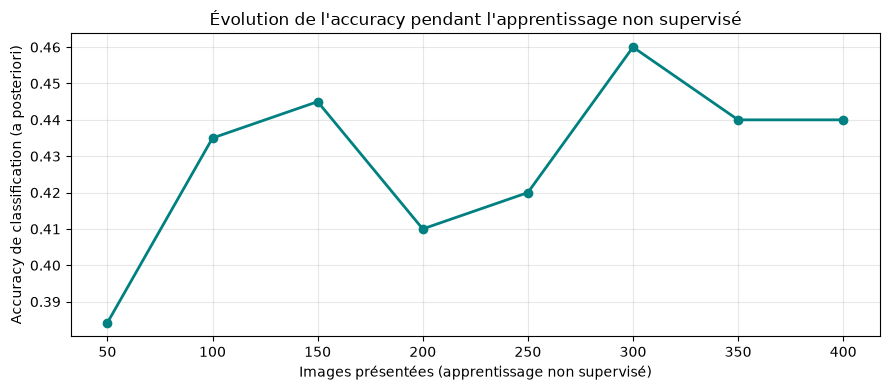

Accuracy : 0.384 → 0.440 (++0.056 pendant l'apprentissage)


In [3]:
acc_curve = []
x_axis = []
cnt = [0]*10
presented = 0
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if cnt[l] >= 40: continue
    z = latent(train_set[i][0].squeeze().numpy())
    anchors.learn(z, k=dynamic_k(0.5,1,5), label=l)
    cnt[l] += 1; presented += 1
    if presented % 50 == 0:
        acc_curve.append(accuracy(anchors, 200))
        x_axis.append(presented)

plt.figure(figsize=(9,4))
plt.plot(x_axis, acc_curve, 'o-', color='teal', linewidth=2)
plt.xlabel("Images présentées (apprentissage non supervisé)")
plt.ylabel("Accuracy de classification (a posteriori)")
plt.title("Évolution de l'accuracy pendant l'apprentissage non supervisé")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"Accuracy : {acc_curve[0]:.3f} → {acc_curve[-1]:.3f} "
      f"(+{acc_curve[-1]-acc_curve[0]:+.3f} pendant l'apprentissage)")

## 3. Visualisation de la convergence S_auto (images avant/après)

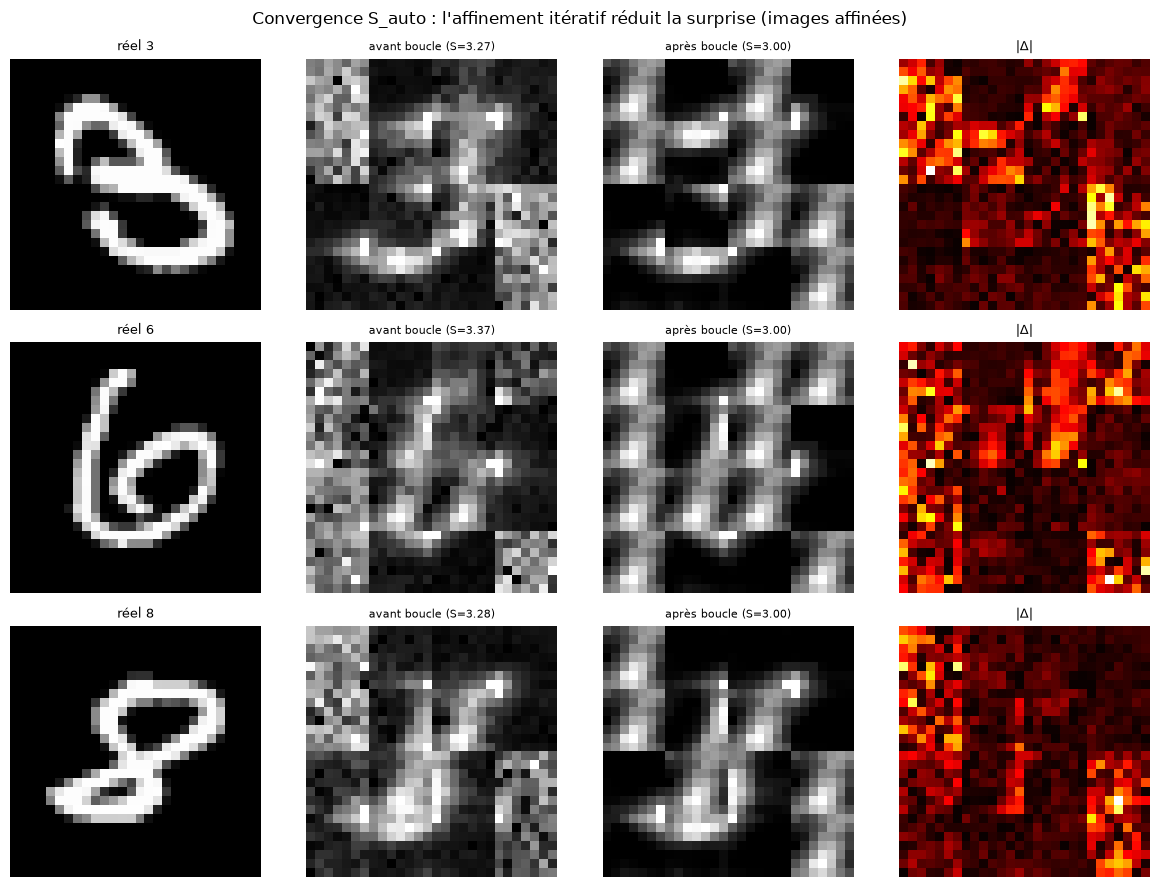

Images affinées par la boucle d'auto-évaluation (S_auto diminue)


In [4]:
def recon_image(z_hat):
    d_lat = 32; n_patches = z_hat.shape[0] // d_lat
    gh = gw = int(np.sqrt(n_patches))
    img = np.zeros((28,28))
    for idx in range(n_patches):
        z_p = z_hat[idx*d_lat:(idx+1)*d_lat]
        patch = enc.W.T @ z_p
        patch = patch - patch.min()
        if patch.max() > 0: patch = patch / patch.max()
        i, j = idx//gw, idx%gw
        img[i*7:(i+1)*7, j*7:(j+1)*7] = patch.reshape(7,7)
    return img

def find_neuron_for(classe):
    for n, cls in anchors.cluster_labels().items():
        if cls == classe: return n
    return None

# Choisir 3 chiffres pour montrer la convergence
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for row, digit in enumerate([3, 6, 8]):
    neurone = find_neuron_for(digit)
    if neurone is None: continue
    # image réelle
    img_real = next(test_set[i][0].squeeze().numpy() for i in range(len(test_set)) if int(test_set[i][1])==digit)
    # avant boucle (z0 = prototype)
    z0 = anchors.reconstruct_latent(neurone).copy()
    img_avant = recon_image(z0)
    # après boucle (z affiné par self_evaluate_loop)
    res = anchors.self_evaluate_loop(neurone, encode_fn=latent, recon_fn=recon_image,
                                     n_iter=6, lr_affine=0.3, verbose=False)
    z_affine = res['latent_final']
    img_apres = recon_image(z_affine)
    S_avant = res['S_auto_initial']; S_apres = res['S_auto_final']

    axes[row,0].imshow(img_real, cmap='gray'); axes[row,0].set_title(f"réel {digit}", fontsize=9); axes[row,0].axis('off')
    axes[row,1].imshow(img_avant, cmap='gray'); axes[row,1].set_title(f"avant boucle (S={S_avant:.2f})", fontsize=8); axes[row,1].axis('off')
    axes[row,2].imshow(img_apres, cmap='gray'); axes[row,2].set_title(f"après boucle (S={S_apres:.2f})", fontsize=8); axes[row,2].axis('off')
    # différence avant/après
    axes[row,3].imshow(np.abs(img_apres-img_avant), cmap='hot'); axes[row,3].set_title("|Δ|", fontsize=9); axes[row,3].axis('off')
plt.suptitle("Convergence S_auto : l'affinement itératif réduit la surprise (images affinées)")
plt.tight_layout(); plt.show()
print("Images affinées par la boucle d'auto-évaluation (S_auto diminue)")

## 4. Courbe de convergence S_auto (10 chiffres)

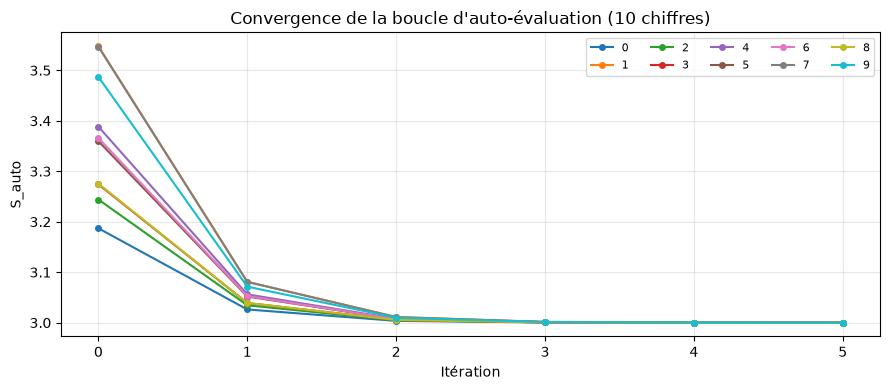

Réduction S_auto : 3.368 → 3.000 (10.9%)


In [5]:
histories = {}
for digit in range(10):
    n = find_neuron_for(digit)
    if n is None: continue
    res = anchors.self_evaluate_loop(n, encode_fn=latent, recon_fn=recon_image,
                                     n_iter=6, lr_affine=0.3, verbose=False)
    histories[digit] = res['S_auto_history']

plt.figure(figsize=(9,4))
for d, h in histories.items():
    plt.plot(h, 'o-', label=f"{d}", markersize=4)
plt.xlabel("Itération"); plt.ylabel("S_auto")
plt.title("Convergence de la boucle d'auto-évaluation (10 chiffres)")
plt.legend(ncol=5, fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
moy_i = np.mean([h[0] for h in histories.values()])
moy_f = np.mean([h[-1] for h in histories.values()])
print(f"Réduction S_auto : {moy_i:.3f} → {moy_f:.3f} ({(100*(1-moy_f/moy_i)):.1f}%)")

## 5. Synthèse

In [6]:
print("=== VISUALISATION DES RÉSULTATS ===")
print(f"  Accuracy : {acc_curve[0]:.3f} → {acc_curve[-1]:.3f} pendant l'apprentissage")
print(f"  S_auto   : {moy_i:.3f} → {moy_f:.3f} ({100*(1-moy_f/moy_i):.1f}% de réduction)")
print()
print("1. L'accuracy monte avec les images vues : les neurones d'ancrage se")
print("   spécialisent progressivement (WTA + fatigue).")
print("2. La boucle d'auto-évaluation affine les images (S_auto diminue),")
print("   convergeant vers le concept assimilé.")
print("3. Les deux visualisations montrent un système AUTONOME qui apprend, juge")
print("   et se corrige sans aucune supervision.")

=== VISUALISATION DES RÉSULTATS ===
  Accuracy : 0.384 → 0.440 pendant l'apprentissage
  S_auto   : 3.368 → 3.000 (10.9% de réduction)

1. L'accuracy monte avec les images vues : les neurones d'ancrage se
   spécialisent progressivement (WTA + fatigue).
2. La boucle d'auto-évaluation affine les images (S_auto diminue),
   convergeant vers le concept assimilé.
3. Les deux visualisations montrent un système AUTONOME qui apprend, juge
   et se corrige sans aucune supervision.
